# TCN Single-Step — MOGWO-Optimized Final Evaluation (H=1)

**Author:** Ibrahim Hanafy  
**Date:** August 2026  

**All MIT-BIH patients** — auto-discovered from dataset directory.

**Purpose:** Evaluate MOGWO-optimized TCN on **single-step (H=1)** prediction for comparison with H=10 results (NEW_SET.ipynb).

**Best hyperparameters from MOGWO search (Eval 28, pilot RMSE=0.026148):**

| Parameter | Value | Source |
|-----------|-------|--------|
| `n_filters` | 128 | MOGWO Pareto-best (RMSE) |
| `dropout` | 0.131 | MOGWO Pareto-best |
| `lr` | 0.00451 | MOGWO Pareto-best |
| `n_blocks` | 3 | Fixed (RF=29 ≫ lookback=10) |
| `kernel_size` | 3 | Fixed |
| `batch_size` | 128 | Fixed |

**Evaluation:** All patients × H=1, 200 epochs, patience=50

---

## 1 — Imports & Setup

In [1]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.5 MB/s eta 0:00:00


In [2]:
import os, time, gc, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2 — Configuration

In [4]:
# ── Dataset ───────────────────────────────────────────────────────────────────
DATA_DIR = r"/kaggle/input/datasets/rracer17/mit-bih-mitdb/mit-bih-arrhythmia-database-1.0.0"

# ── Paper constants ──────────────────────────────────────────────────────────
FS           = 360
TOTAL_STEPS  = 100_000
TRAIN_STEPS  = 40_000
VAL_STEPS    = 10_000
TEST_STEPS   = 50_000
LOOKBACK     = 10
HORIZON      = 1    # ◄── Single-step prediction

# ── Auto-discover ALL patients in MIT-BIH dataset ─────────────────────────
PATIENTS = sorted(set(
    os.path.splitext(os.path.basename(f))[0]
    for f in glob.glob(os.path.join(DATA_DIR, '*.hea'))
))
print(f'Discovered {len(PATIENTS)} patients: {PATIENTS}')

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  MOGWO-OPTIMIZED HYPERPARAMETERS                                       │
# │  Source: MOGWO Pareto-best (Eval 28), pilot RMSE = 0.026148            │
# │  Search: 5 wolves × 5 iters = 30 evals, 5 pilot patients, H=10       │
# └──────────────────────────────────────────────────────────────────────────┘
NUM_FILTERS   = 128
DROPOUT_RATE  = 0.131
LEARNING_RATE = 0.00451
NUM_BLOCKS    = 3     # RF = 29 ≫ lookback=10
KERNEL_SIZE   = 3
BATCH_SIZE    = 128

# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS   = 200
PATIENCE = 50

# ── Output ───────────────────────────────────────────────────────────────────
OUT_DIR   = '/kaggle/working'
PLOT_DIR  = os.path.join(OUT_DIR, 'plots_comparison_h1')
CSV_NAME  = os.path.join(OUT_DIR, 'tcn_mogwo_comparison_h1_results.csv')
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── 10 random patients for signal visualization ──────────────────────────────
VIZ_PATIENTS = sorted(np.random.choice(PATIENTS, size=min(10, len(PATIENTS)),
                                       replace=False).tolist())

print(f'\nConfig    : MOGWO-Optimized (H=1 Comparison)')
print(f'Patients  : {len(PATIENTS)} (all MIT-BIH)')
print(f'Viz sample: {len(VIZ_PATIENTS)} → {VIZ_PATIENTS}')
print(f'Horizon   : H={HORIZON} (single-step)')
print(f'TCN       : blocks={NUM_BLOCKS}, filters={NUM_FILTERS}, kernel={KERNEL_SIZE}')
print(f'Dropout   : {DROPOUT_RATE}')
print(f'Training  : epochs={EPOCHS}, patience={PATIENCE}, batch={BATCH_SIZE}, lr={LEARNING_RATE}')

Discovered 48 patients: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

Config    : MOGWO-Optimized (H=1 Comparison)
Patients  : 48 (all MIT-BIH)
Viz sample: 10 → ['104', '113', '121', '201', '202', '203', '205', '219', '222', '230']
Horizon   : H=1 (single-step)
TCN       : blocks=3, filters=128, kernel=3
Dropout   : 0.131
Training  : epochs=200, patience=50, batch=128, lr=0.00451


## 3 — Data Pipeline

In [5]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    """Load MLII lead from MIT-BIH, truncate/pad to n_steps."""
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def preprocess_patient(signal, train_steps=40_000, val_steps=10_000):
    """Split → train/val/test, MinMax-normalise (fit on train only)."""
    train_end = train_steps
    val_end   = train_steps + val_steps
    train_raw = signal[:train_end]
    val_raw   = signal[train_end:val_end]
    test_raw  = signal[val_end:]
    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    return train_norm, val_norm, test_norm, scaler


def make_sequences(signal, lookback, horizon):
    """Sliding-window: X = (lookback,) -> y = (horizon,)."""
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def compute_metrics(y_true, y_pred):
    yt, yp = y_true.flatten(), y_pred.flatten()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
    }


print('Data pipeline defined.')

Data pipeline defined.


In [6]:
# ── Load ALL patients ─────────────────────────────────────────────────────────
patient_signals = {}

print(f'Loading {len(PATIENTS)} patients...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)
    patient_signals[rid] = {'train': tr, 'val': vl, 'test': te, 'scaler': sc}
    tqdm.write(f'  Patient {rid:>3s} | train={len(tr):,}  val={len(vl):,}  test={len(te):,}')

print(f'\nAll {len(patient_signals)} patients loaded.')

Loading 48 patients...



Patients:   0%|          | 0/48 [00:00<?, ?it/s]

  Patient 100 | train=40,000  val=10,000  test=50,000
  Patient 101 | train=40,000  val=10,000  test=50,000
  Patient 102 | train=40,000  val=10,000  test=50,000
  Patient 103 | train=40,000  val=10,000  test=50,000
  Patient 104 | train=40,000  val=10,000  test=50,000
  Patient 105 | train=40,000  val=10,000  test=50,000
  Patient 106 | train=40,000  val=10,000  test=50,000
  Patient 107 | train=40,000  val=10,000  test=50,000
  Patient 108 | train=40,000  val=10,000  test=50,000
  Patient 109 | train=40,000  val=10,000  test=50,000
  Patient 111 | train=40,000  val=10,000  test=50,000
  Patient 112 | train=40,000  val=10,000  test=50,000
  Patient 113 | train=40,000  val=10,000  test=50,000
  Patient 114 | train=40,000  val=10,000  test=50,000
  Patient 115 | train=40,000  val=10,000  test=50,000
  Patient 116 | train=40,000  val=10,000  test=50,000
  Patient 117 | train=40,000  val=10,000  test=50,000
  Patient 118 | train=40,000  val=10,000  test=50,000
  Patient 119 | train=40,000

## 4 — Model Architecture

Same TCN as NEW_SET (H=10). Only change: output Dense has 1 neuron instead of 10.

In [7]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1)(x)
    return Add()([x, out])


def build_tcn(lookback, output_size, n_blocks, n_filters, kernel_size, dropout_rate, learning_rate):
    inp = Input(shape=(lookback, 1))
    x = inp
    for i in range(n_blocks):
        x = residual_block(x, n_filters, kernel_size, 2 ** i, dropout_rate)
    x = x[:, -1, :]
    x = Dense(n_filters, activation='relu')(x)
    out = Dense(output_size)(x)
    model = Model(inp, out, name=f'TCN_H{output_size}')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss='mse')
    return model


# ── Parameter count ───────────────────────────────────────────────────────────
demo = build_tcn(LOOKBACK, HORIZON, NUM_BLOCKS, NUM_FILTERS, KERNEL_SIZE,
                 DROPOUT_RATE, LEARNING_RATE)
print(f'TCN H={HORIZON}: {demo.count_params():,} params')
demo.summary()
del demo

I0000 00:00:1786973874.409622      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786973874.412527      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TCN H=1: 266,881 params


Model: "TCN_H1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 128)   │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 128)   │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 128)   │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 128)   │     49,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 128)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 128)   │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 128)   │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10, 128)   │     49,280 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 128)   │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 10, 128)   │     49,280 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 10, 128)   │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 128)   │          0 │ add[0][0],      

 Total params: 266,881 (1.02 MB)

 Trainable params: 265,345 (1.01 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 5 — Train & Evaluate All Patients

In [8]:
results            = []
saved_preds        = {}
training_histories = {}

print(f'Running: {len(PATIENTS)} patients × H={HORIZON}')
print(f'Config : blocks={NUM_BLOCKS}, filters={NUM_FILTERS}, kernel={KERNEL_SIZE}, '
      f'dropout={DROPOUT_RATE}, lr={LEARNING_RATE}, batch={BATCH_SIZE}')
print('=' * 80)

for rid in tqdm(PATIENTS, desc='Patients'):
    tf.keras.backend.clear_session()
    gc.collect()

    tr = patient_signals[rid]['train']
    vl = patient_signals[rid]['val']
    te = patient_signals[rid]['test']

    X_tr, y_tr = make_sequences(tr, LOOKBACK, HORIZON)
    X_vl, y_vl = make_sequences(vl, LOOKBACK, HORIZON)
    X_te, y_te = make_sequences(te, LOOKBACK, HORIZON)

    X_tr_r = X_tr.reshape(-1, X_tr.shape[1], 1)
    X_vl_r = X_vl.reshape(-1, X_vl.shape[1], 1)
    X_te_r = X_te.reshape(-1, X_te.shape[1], 1)

    t0 = time.time()
    model = build_tcn(LOOKBACK, HORIZON,
                      NUM_BLOCKS, NUM_FILTERS, KERNEL_SIZE,
                      DROPOUT_RATE, LEARNING_RATE)

    history = model.fit(
        X_tr_r, y_tr,
        validation_data=(X_vl_r, y_vl),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=25, min_lr=1e-6),
        ],
        verbose=0
    )

    preds = model.predict(X_te_r, batch_size=2048, verbose=0)
    elapsed = time.time() - t0

    m = compute_metrics(y_te, preds)
    m['Time_s'] = round(elapsed, 2)
    m['Epochs_trained'] = len(history.history['loss'])
    results.append({'Patient': rid, 'Horizon': HORIZON, **m})

    saved_preds[rid] = (y_te.copy(), preds.copy())
    training_histories[rid] = {
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
    }

    del model
    gc.collect()

    tqdm.write(
        f'  Patient {rid} | R²={m["R2"]:.4f}  RMSE={m["RMSE"]:.6f}  '
        f'MAE={m["MAE"]:.6f}  ({m["Epochs_trained"]} ep, {elapsed:.1f}s)'
    )

print(f'\nAll {len(results)} patients complete.')

Running: 48 patients × H=1
Config : blocks=3, filters=128, kernel=3, dropout=0.131, lr=0.00451, batch=128


Patients:   0%|          | 0/48 [00:00<?, ?it/s]

I0000 00:00:1786973887.650146      80 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Patient 100 | R²=0.9965  RMSE=0.005702  MAE=0.004215  (200 ep, 309.4s)
  Patient 101 | R²=0.9929  RMSE=0.009267  MAE=0.003988  (200 ep, 305.2s)
  Patient 102 | R²=0.9954  RMSE=0.004603  MAE=0.003457  (200 ep, 309.8s)
  Patient 103 | R²=0.9988  RMSE=0.003987  MAE=0.002961  (200 ep, 310.8s)
  Patient 104 | R²=0.9914  RMSE=0.009689  MAE=0.006444  (150 ep, 236.1s)
  Patient 105 | R²=0.9981  RMSE=0.005017  MAE=0.003705  (200 ep, 311.0s)
  Patient 106 | R²=0.9980  RMSE=0.004146  MAE=0.003030  (200 ep, 316.9s)
  Patient 107 | R²=0.9994  RMSE=0.003245  MAE=0.002364  (200 ep, 315.8s)
  Patient 108 | R²=0.9908  RMSE=0.008701  MAE=0.006256  (160 ep, 254.1s)
  Patient 109 | R²=0.9988  RMSE=0.004735  MAE=0.003574  (89 ep, 150.1s)
  Patient 111 | R²=0.9957  RMSE=0.006038  MAE=0.004436  (200 ep, 312.0s)
  Patient 112 | R²=0.9976  RMSE=0.005654  MAE=0.004352  (200 ep, 316.3s)
  Patient 113 | R²=0.9991  RMSE=0.003782  MAE=0.002607  (200 ep, 315.9s)
  Patient 114 | R²=0.9980  RMSE=0.002887  MAE=0.0021

In [9]:
# ── Save results ─────────────────────────────────────────────────────────────
df_results = pd.DataFrame(results)
df_results.to_csv(CSV_NAME, index=False)
print(f'Results saved to {CSV_NAME}\n')
display(df_results)

print(f'\n--- Summary (H={HORIZON}, {len(PATIENTS)} patients) ---')
print(f'Mean RMSE : {df_results.RMSE.mean():.6f} ± {df_results.RMSE.std():.6f}')
print(f'Mean MAE  : {df_results.MAE.mean():.6f} ± {df_results.MAE.std():.6f}')
print(f'Mean R²   : {df_results.R2.mean():.4f} ± {df_results.R2.std():.4f}')

Results saved to /kaggle/working/tcn_mogwo_comparison_h1_results.csv



,Patient,Horizon,RMSE,MAE,R2,Time_s,Epochs_trained
0,100,1,0.005702,0.004215,0.996479,309.37,200
1,101,1,0.009267,0.003988,0.992891,305.21,200
2,102,1,0.004603,0.003457,0.995363,309.79,200
3,103,1,0.003987,0.002961,0.998819,310.84,200
4,104,1,0.009689,0.006444,0.991356,236.13,150
5,105,1,0.005017,0.003705,0.998106,311.01,200
6,106,1,0.004146,0.003030,0.998027,316.93,200
7,107,1,0.003245,0.002364,0.999392,315.84,200
8,108,1,0.008701,0.006256,0.990796,254.09,160
9,109,1,0.004735,0.003574,0.998812,150.15,89



--- Summary (H=1, 48 patients) ---
Mean RMSE : 0.005297 ± 0.002039
Mean MAE  : 0.003686 ± 0.001217
Mean R²   : 0.9970 ± 0.0026


## 6 — Visualizations

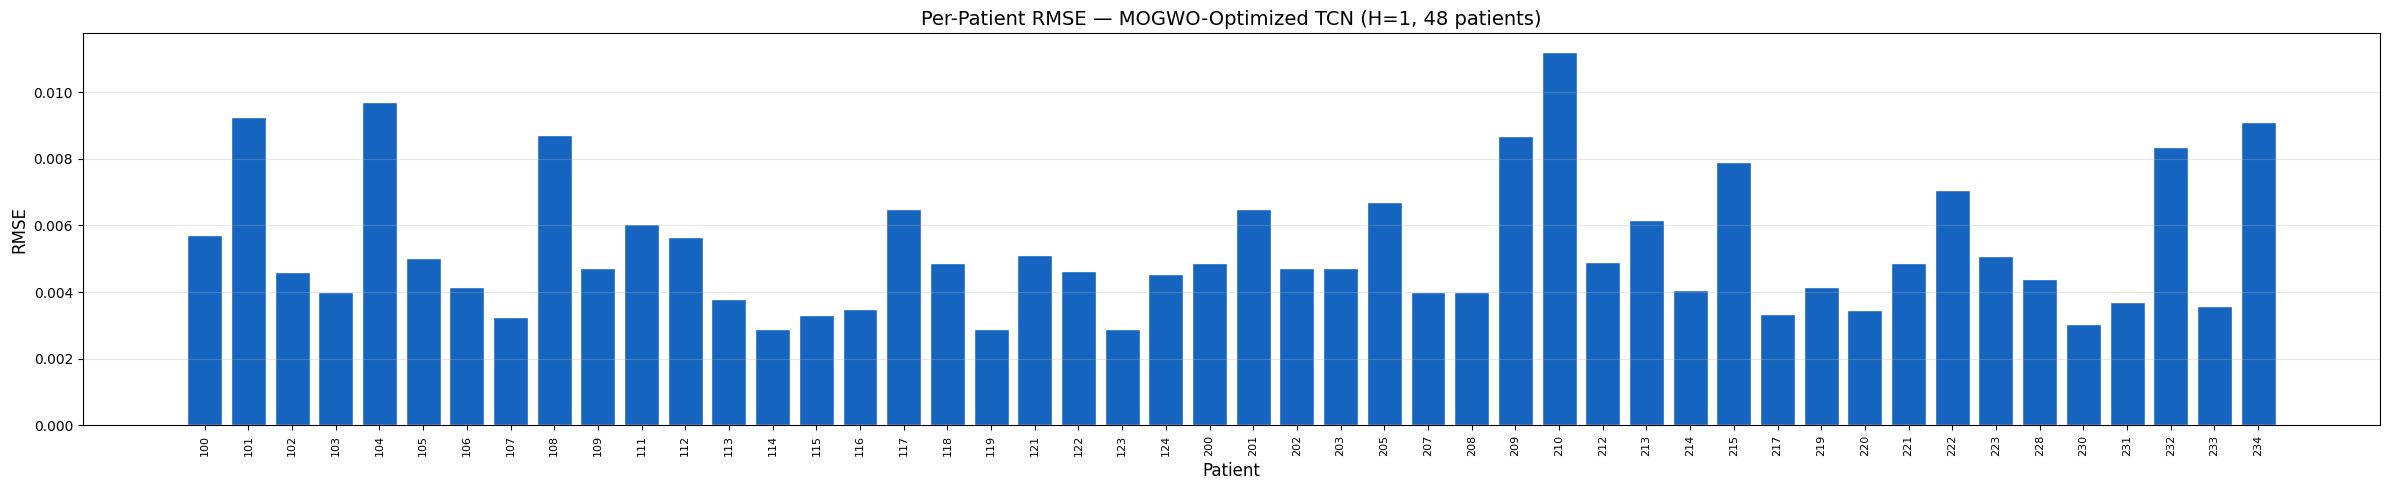

In [10]:
# ── 6.1 Per-Patient RMSE Bar — ALL patients ─────────────────────────────────
df_sorted = df_results.sort_values('Patient').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(max(16, len(PATIENTS) * 0.5), 5))
x = np.arange(len(PATIENTS))

ax.bar(x, df_sorted.RMSE.values, color='#1565C0', edgecolor='white')
ax.set_xlabel('Patient', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title(f'Per-Patient RMSE — MOGWO-Optimized TCN (H={HORIZON}, {len(PATIENTS)} patients)',
             fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted.Patient.values, rotation=90, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_patient_rmse_all.png', dpi=200, bbox_inches='tight')
plt.show()

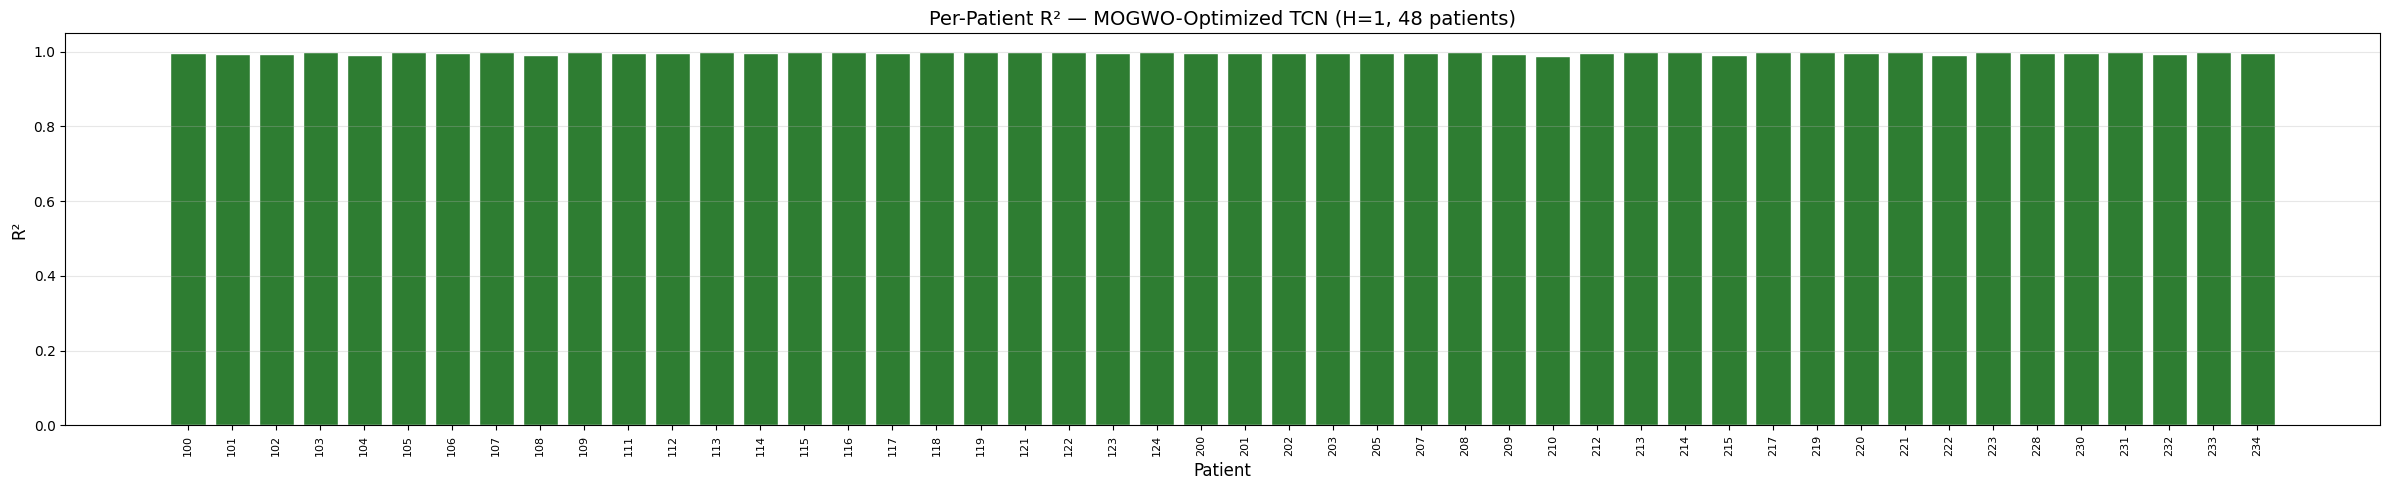

In [11]:
# ── 6.2 Per-Patient R² Bar — ALL patients ────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(16, len(PATIENTS) * 0.5), 5))
ax.bar(x, df_sorted.R2.values, color='#2E7D32', edgecolor='white')
ax.set_xlabel('Patient', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title(f'Per-Patient R² — MOGWO-Optimized TCN (H={HORIZON}, {len(PATIENTS)} patients)',
             fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted.Patient.values, rotation=90, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_patient_r2_all.png', dpi=200, bbox_inches='tight')
plt.show()

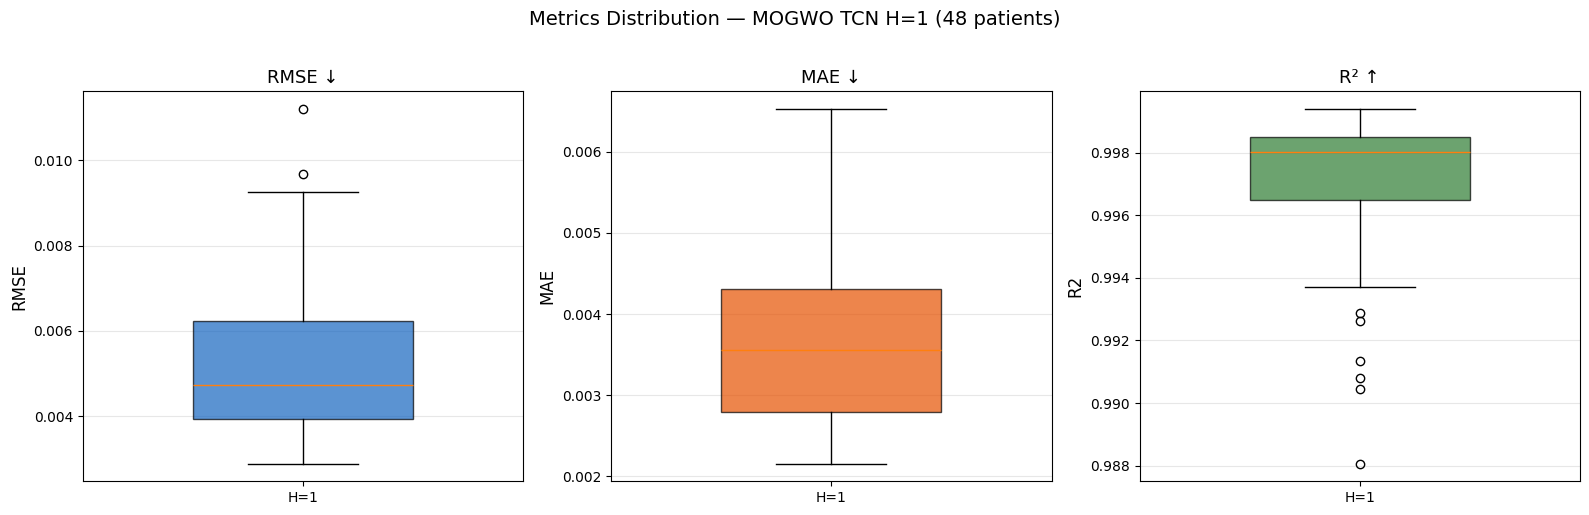

In [12]:
# ── 6.3 Metrics Box Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title, color in zip(
    axes,
    ['RMSE', 'MAE', 'R2'],
    ['RMSE ↓', 'MAE ↓', 'R² ↑'],
    ['#1565C0', '#E65100', '#2E7D32']
):
    bp = ax.boxplot(df_results[metric].values, patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xticklabels([f'H={HORIZON}'])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Metrics Distribution — MOGWO TCN H={HORIZON} ({len(PATIENTS)} patients)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/metrics_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()

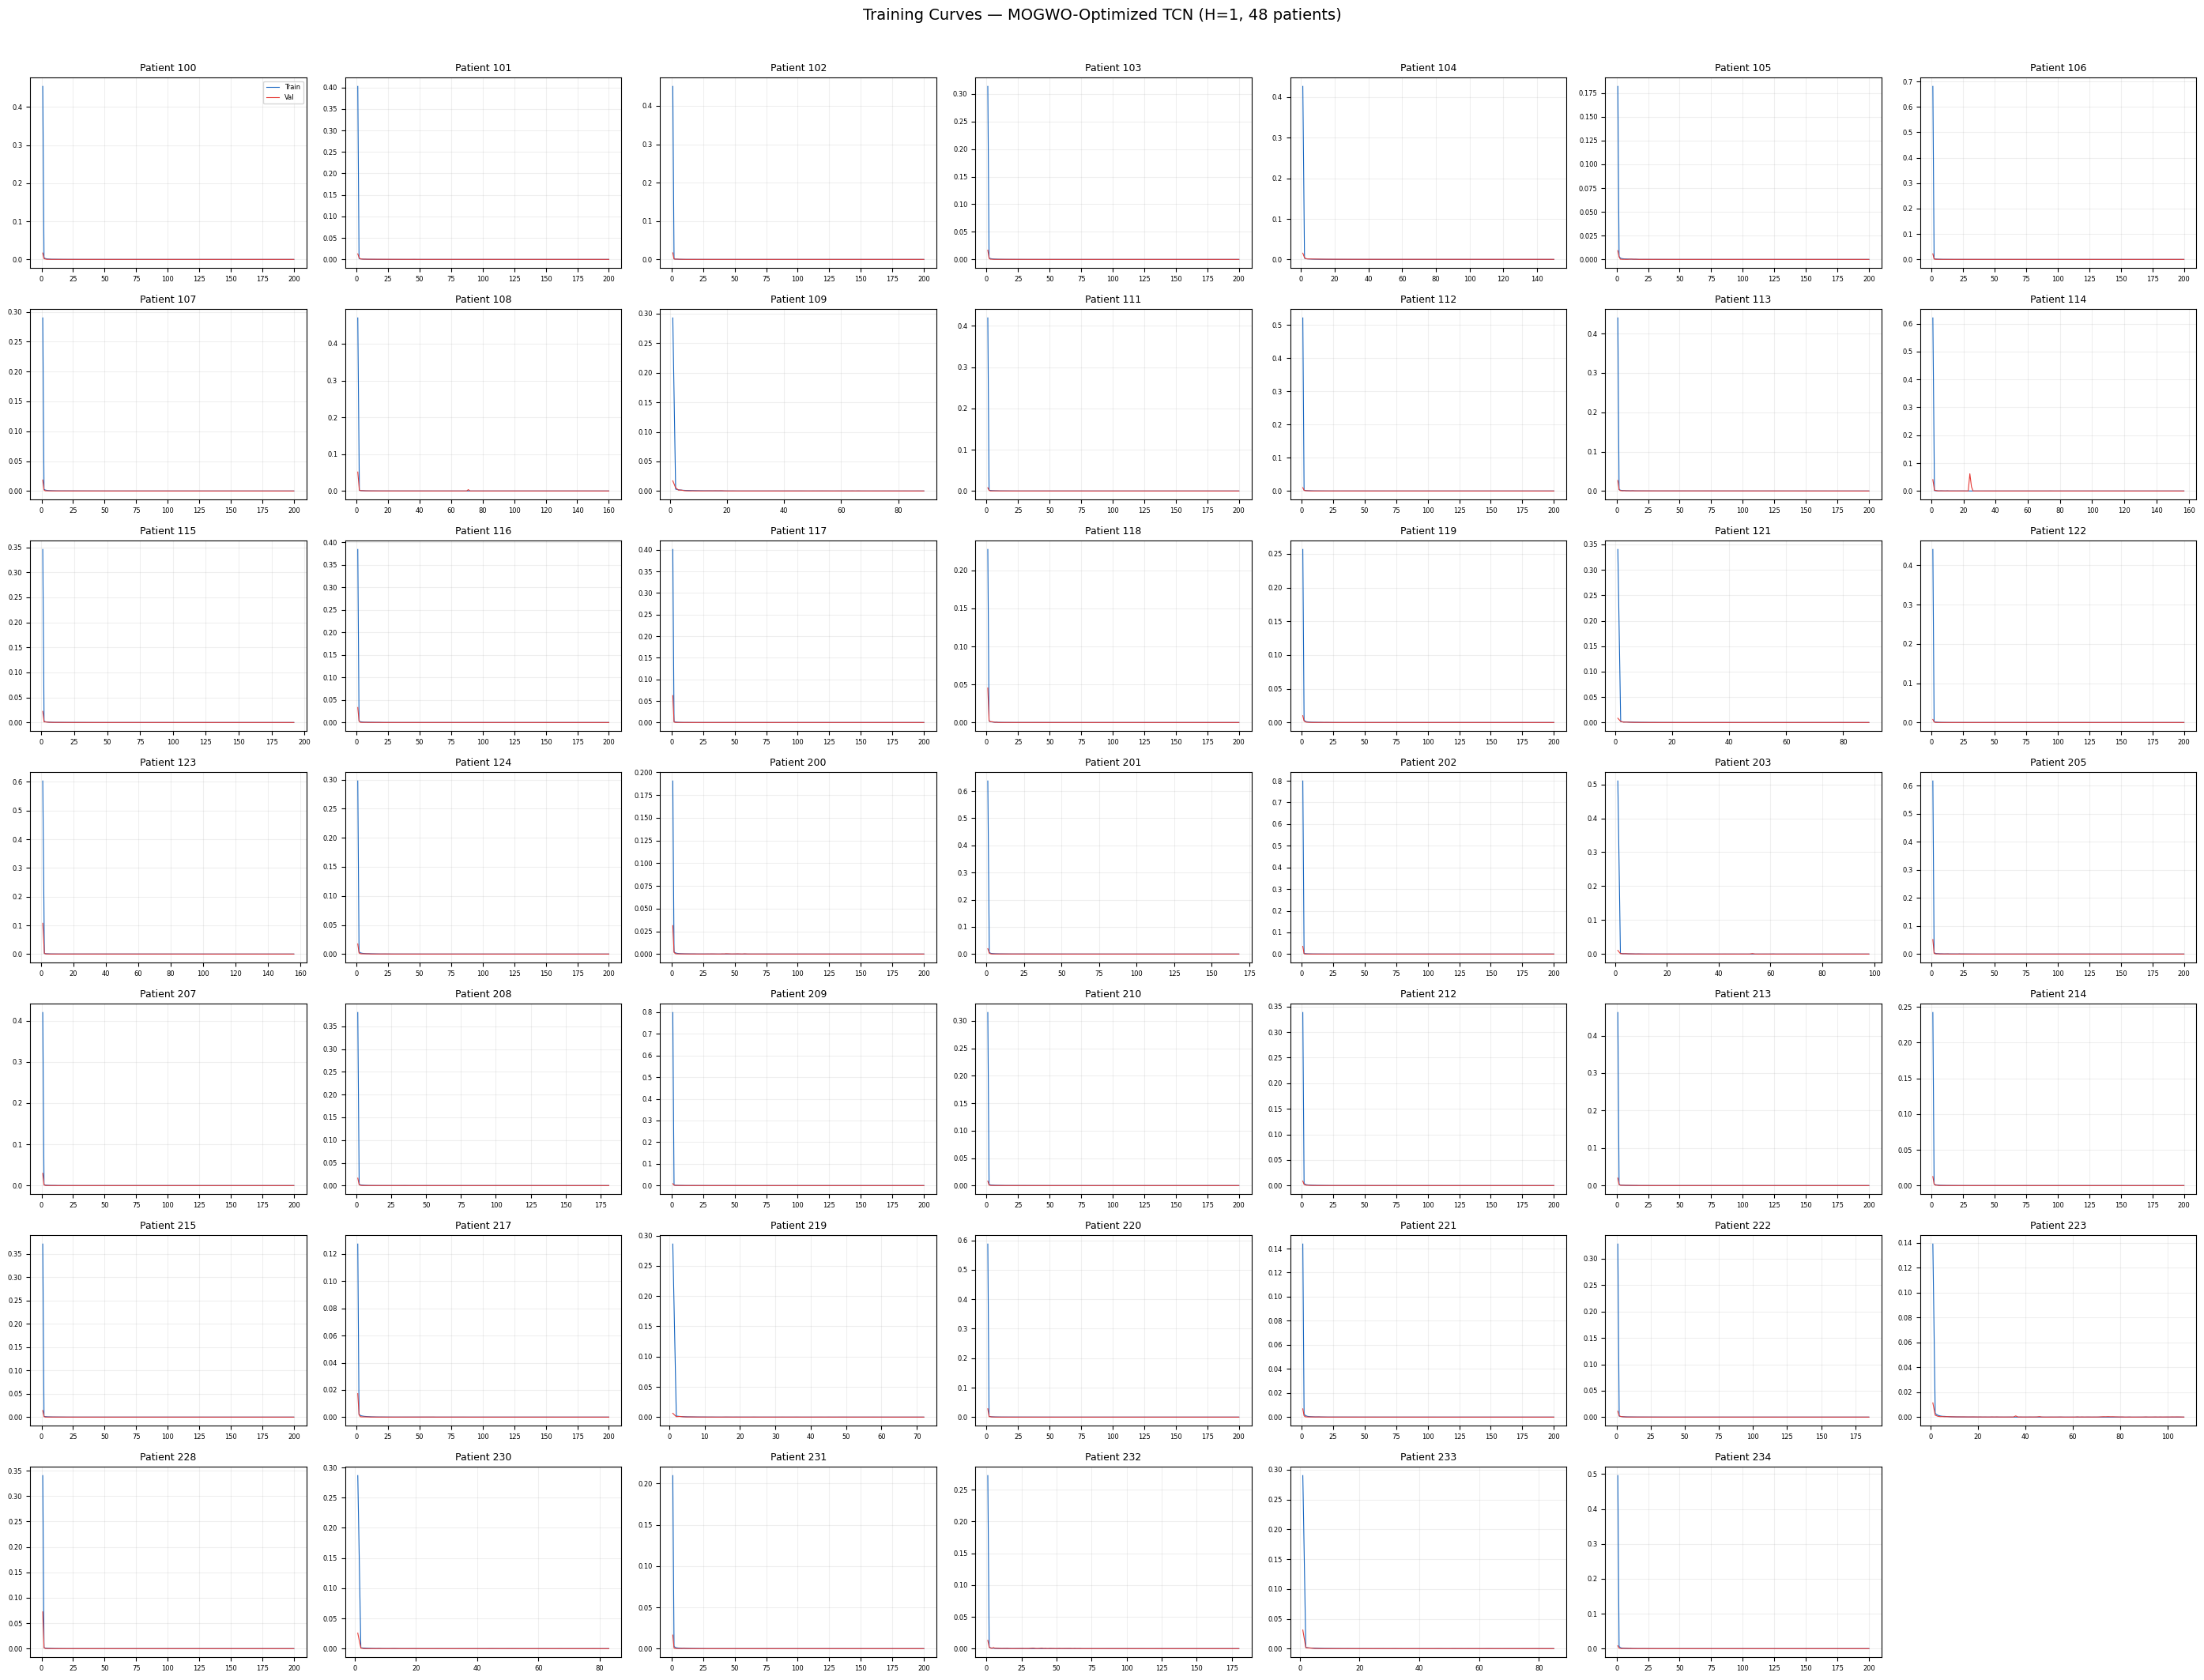

In [13]:
# ── 6.4 Training Curves (all patients) ───────────────────────────────────────
n_patients = len(PATIENTS)
nc = 7
nr = int(np.ceil(n_patients / nc))
fig, axes = plt.subplots(nr, nc, figsize=(4 * nc, 3 * nr), sharey=False)
axes_flat = axes.flatten()

for idx, rid in enumerate(PATIENTS):
    ax = axes_flat[idx]
    hist = training_histories[rid]
    epochs_range = range(1, len(hist['loss']) + 1)
    ax.plot(epochs_range, hist['loss'], label='Train', linewidth=0.8, color='#1565C0')
    ax.plot(epochs_range, hist['val_loss'], label='Val', linewidth=0.8, color='#E53935')
    ax.set_title(f'Patient {rid}', fontsize=9)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=6)

for idx in range(n_patients, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(f'Training Curves — MOGWO-Optimized TCN (H={HORIZON}, {n_patients} patients)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/training_curves_all.png', dpi=200, bbox_inches='tight')
plt.show()

## 7 — Signal Overlay (10 Random Patients)

In [14]:
print(f'Signal visualization patients ({len(VIZ_PATIENTS)}): {VIZ_PATIENTS}')

Signal visualization patients (10): ['104', '113', '121', '201', '202', '203', '205', '219', '222', '230']


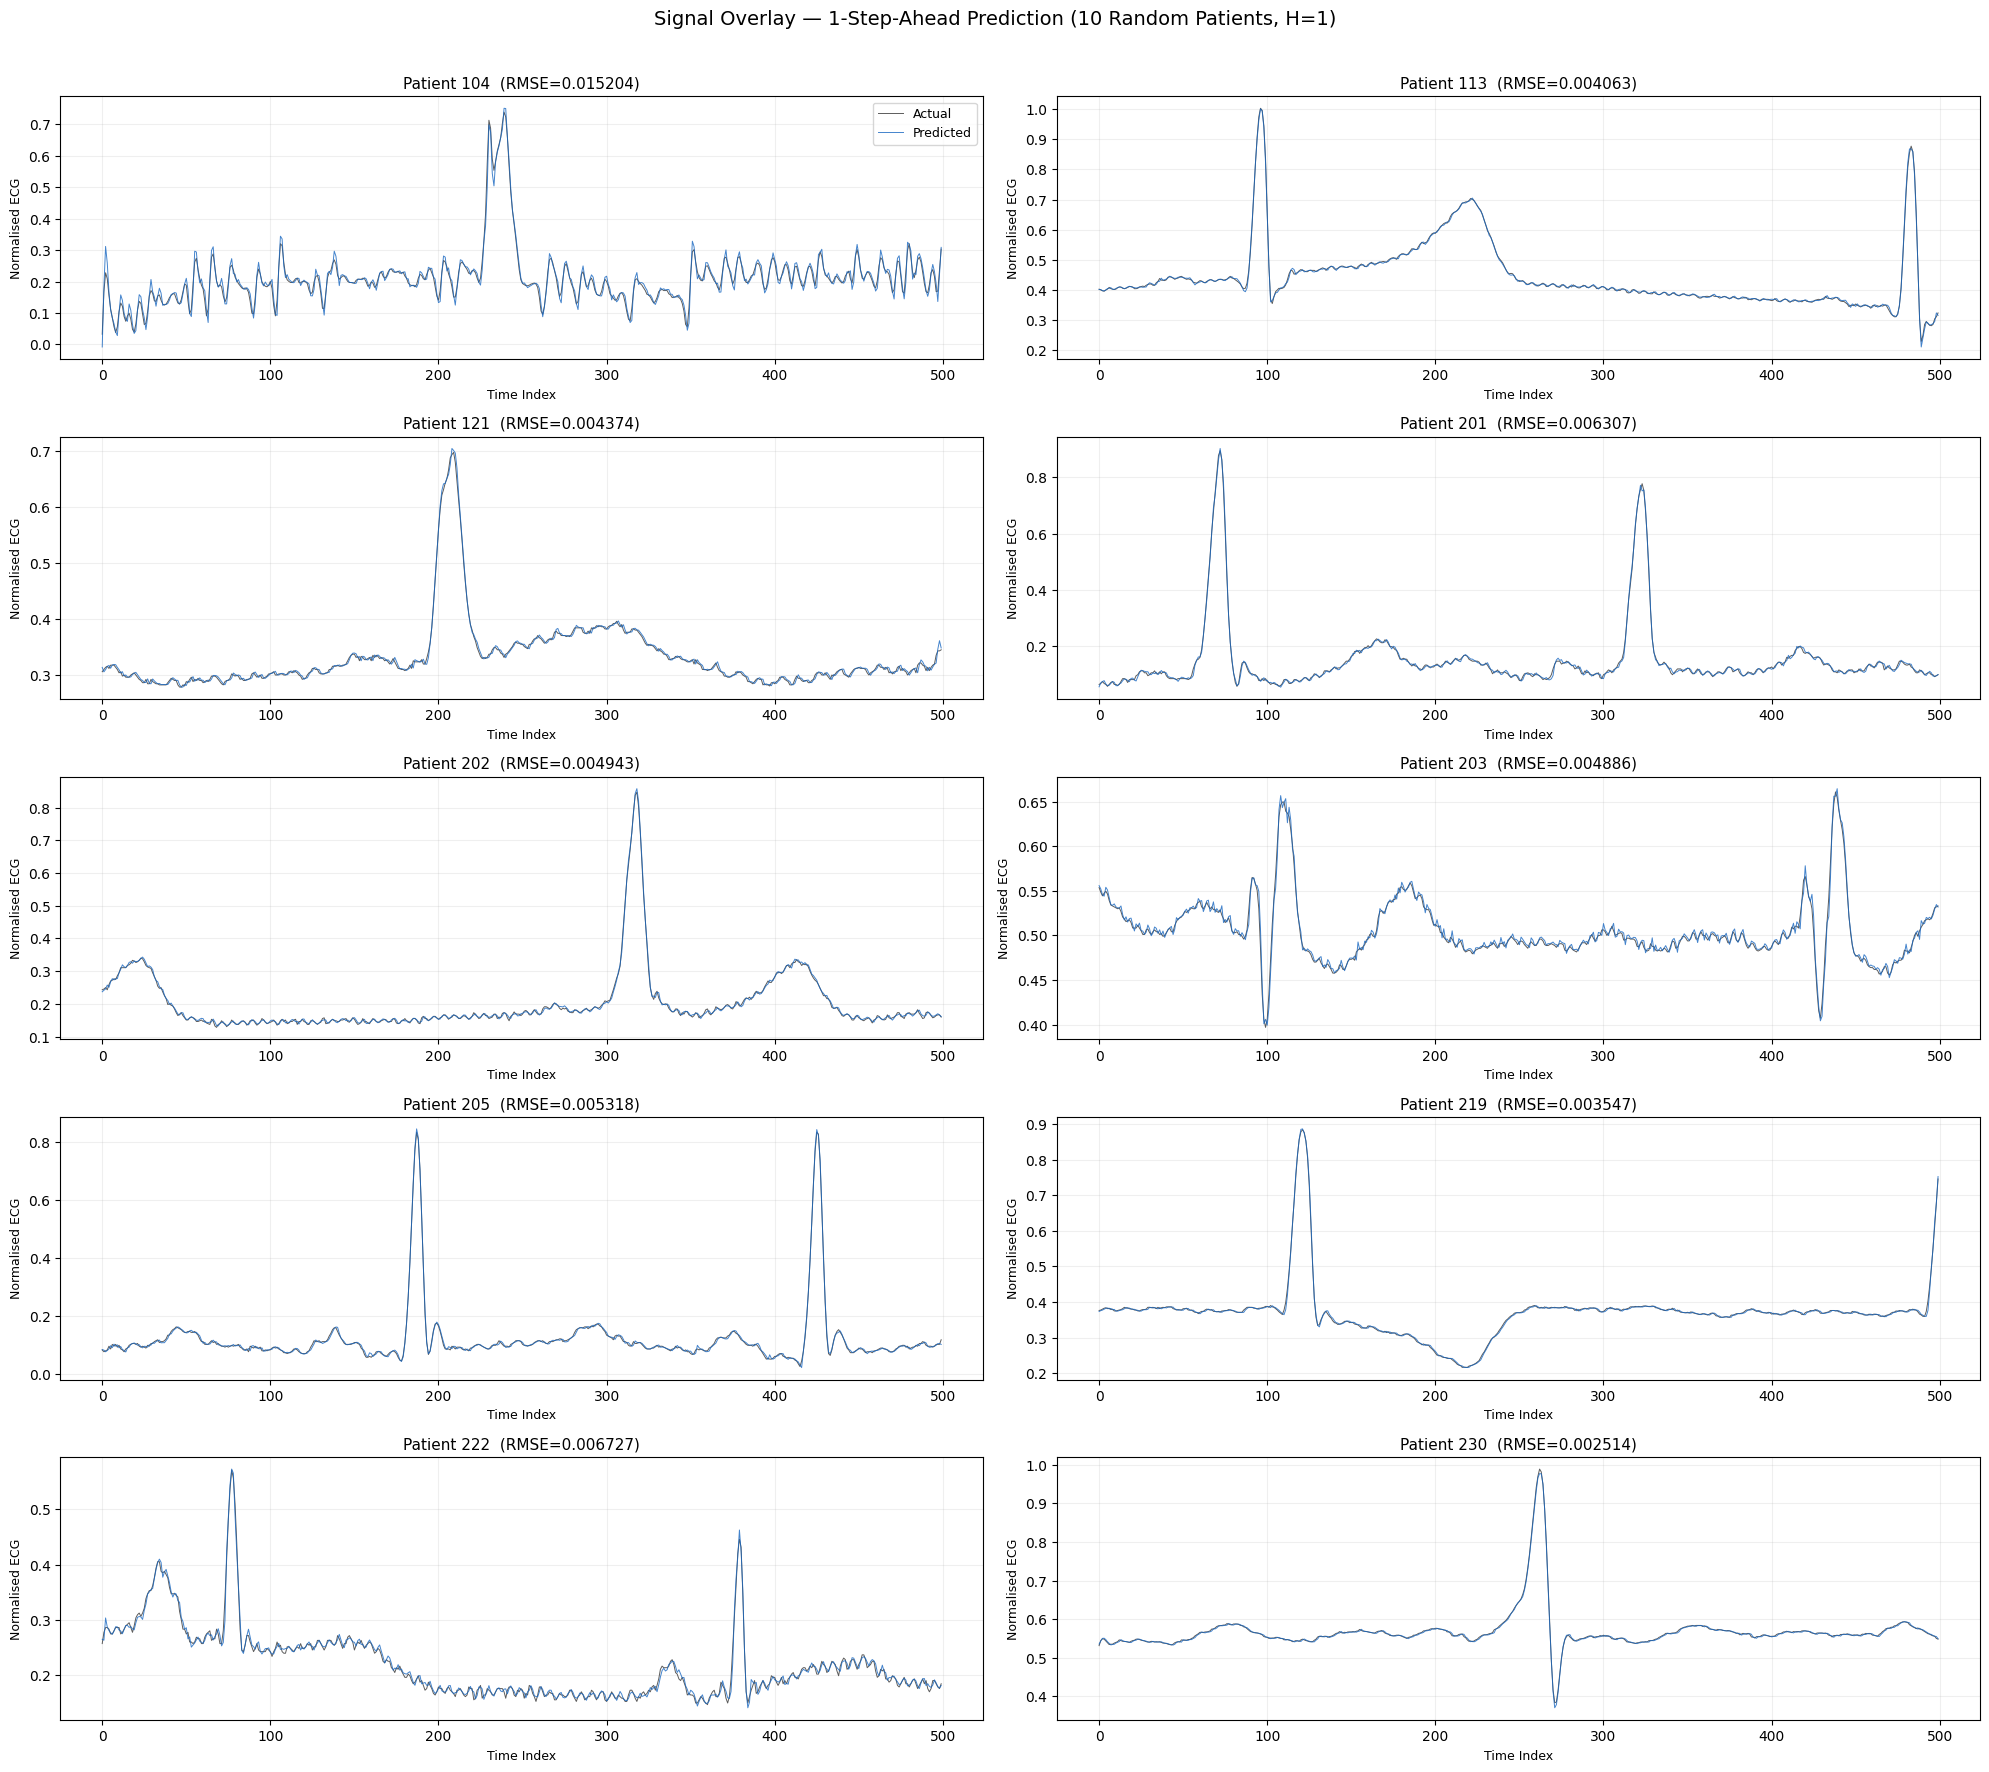

In [15]:
# ── 7.1 Signal Overlay — H=1 (10 Random Patients) ────────────────────────────
N_SHOW = 500
n_viz = len(VIZ_PATIENTS)
nc_viz = 2
nr_viz = int(np.ceil(n_viz / nc_viz))
fig, axes = plt.subplots(nr_viz, nc_viz, figsize=(20, 3.5 * nr_viz))
axes_flat = axes.flatten()

for idx, rid in enumerate(VIZ_PATIENTS):
    ax = axes_flat[idx]
    y_true, y_pred = saved_preds[rid]
    actual    = y_true[:N_SHOW].flatten()
    predicted = y_pred[:N_SHOW].flatten()
    rmse_p = float(np.sqrt(mean_squared_error(actual, predicted)))

    ax.plot(actual, color='#333333', linewidth=0.7, alpha=0.8, label='Actual')
    ax.plot(predicted, color='#1565C0', linewidth=0.7, alpha=0.8, label='Predicted')
    ax.set_title(f'Patient {rid}  (RMSE={rmse_p:.6f})', fontsize=11)
    ax.set_xlabel('Time Index', fontsize=9)
    ax.set_ylabel('Normalised ECG', fontsize=9)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=9, loc='upper right')

for idx in range(n_viz, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(f'Signal Overlay — 1-Step-Ahead Prediction (10 Random Patients, H={HORIZON})',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/signal_overlay_h1.png', dpi=200, bbox_inches='tight')
plt.show()

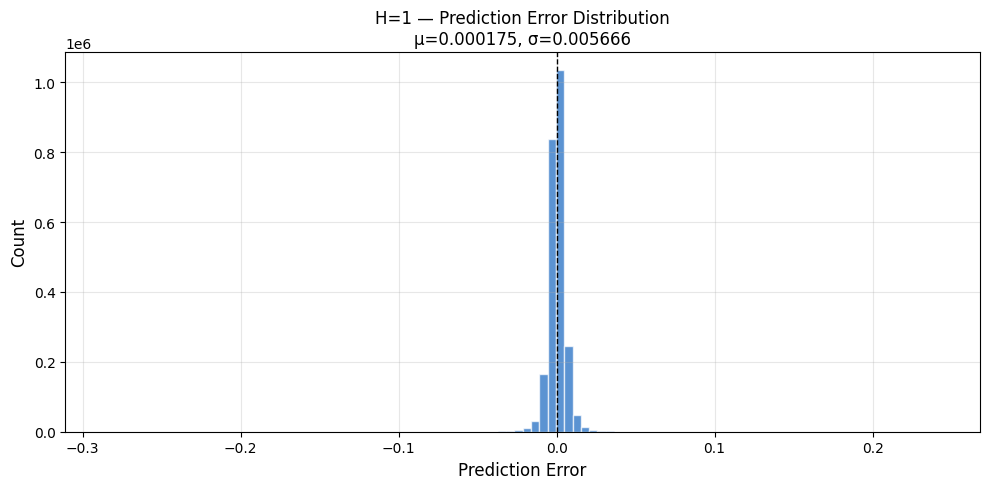

In [16]:
# ── 7.2 Error Distribution (all patients) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

all_errors = []
for rid in PATIENTS:
    y_true, y_pred = saved_preds[rid]
    errors = y_pred.flatten() - y_true.flatten()
    all_errors.append(errors)
all_errors = np.concatenate(all_errors)

ax.hist(all_errors, bins=100, color='#1565C0', alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Prediction Error', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'H={HORIZON} — Prediction Error Distribution\n'
             f'μ={all_errors.mean():.6f}, σ={all_errors.std():.6f}',
             fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/error_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## 8 — Summary

In [17]:
print('\n' + '=' * 80)
print('MOGWO-OPTIMIZED TCN — H=1 SINGLE-STEP EVALUATION COMPLETE')
print('=' * 80)

print(f'\nConfiguration (from MOGWO Pareto-best):')
print(f'  n_filters     = {NUM_FILTERS}')
print(f'  dropout       = {DROPOUT_RATE}')
print(f'  lr            = {LEARNING_RATE}')
print(f'  n_blocks      = {NUM_BLOCKS} (fixed, RF=29)')
print(f'  kernel_size   = {KERNEL_SIZE} (fixed)')
print(f'  batch_size    = {BATCH_SIZE} (fixed)')

print(f'\nResults (H={HORIZON}, {len(PATIENTS)} patients — ALL MIT-BIH):')
print(f'  Mean RMSE     = {df_results.RMSE.mean():.6f} ± {df_results.RMSE.std():.6f}')
print(f'  Mean MAE      = {df_results.MAE.mean():.6f} ± {df_results.MAE.std():.6f}')
print(f'  Mean R²       = {df_results.R2.mean():.4f} ± {df_results.R2.std():.4f}')
print(f'  Total time    = {df_results.Time_s.sum():.1f}s')

print(f'\nOutputs saved to {OUT_DIR}/:')
print(f'  {os.path.basename(CSV_NAME)}')
print(f'  {os.path.basename(PLOT_DIR)}/ (all plots)')
print('=' * 80)


MOGWO-OPTIMIZED TCN — H=1 SINGLE-STEP EVALUATION COMPLETE

Configuration (from MOGWO Pareto-best):
  n_filters     = 128
  dropout       = 0.131
  lr            = 0.00451
  n_blocks      = 3 (fixed, RF=29)
  kernel_size   = 3 (fixed)
  batch_size    = 128 (fixed)

Results (H=1, 48 patients — ALL MIT-BIH):
  Mean RMSE     = 0.005297 ± 0.002039
  Mean MAE      = 0.003686 ± 0.001217
  Mean R²       = 0.9970 ± 0.0026
  Total time    = 13510.5s

Outputs saved to /kaggle/working/:
  tcn_mogwo_comparison_h1_results.csv
  plots_comparison_h1/ (all plots)
